<div align="center">

# **DecisionTree Project Notebook**

</div>

### **Notebook Purpose**
This notebook guides you through building an Enhanced Decision Tree for a real-world classification problem.

You will learn how the tree handles imbalanced data, how to engineer and select features, how impurity measures work, and how different training strategies affect the final model.
### **Learning Goals**

* Complete the Enhanced DecisionTree and Node classes
* Implement weighted Gini, weighted Entropy, and Information Gain
* Understand how numerical and categorical splits are created
* Learn how class weights, threshold tuning, and cost-sensitive learning improve minority‑class recall
* Apply feature engineering and Gini-based feature selection
* Train multiple tree configurations and compare their performance

### **Tasks**
Finish all the TODO parts in the enhanced library and follow each step of this notebook to build a fully working Enhanced Decision Tree classifier and analyze its performance under multiple strategies.



# **Libraries Imports**
Import required libraries and add the DecisionTree and Node classes.


In [5]:
# ============================================================================
# LIBRARY IMPORTS
# ============================================================================

import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# ============================================================================
# DECISION TREE CLASSES IMPORT
# ============================================================================

from DT_Library import Node, DecisionTree, heatmap_gini_filter_clean


## **Part 1 — Node Class**

### **What is a Node?**

What is a Node?
A Node is the basic building block of the Decision Tree.

Each Node can be:

an internal node (splits data based on a feature and threshold), or
a leaf node (stores the final predicted class)

Follow the TODOs carefully—later parts of the notebook and all tree operations depend on this class working correctly.

In [6]:
n1 = Node(feature=3, threshold=1.5, samples=10, impurity=0.4)
assert n1.feature == 3, "Feature index not set correctly."
assert n1.threshold == 1.5, "Threshold not set correctly."
assert n1.samples == 10, "Samples not set correctly."
assert n1.impurity == 0.4, "Impurity not set correctly."

n2 = Node()
n3 = Node()
n2.class_counts[0] = 5
assert len(n3.class_counts) == 0, "class_counts dictionary is shared across instances! Check your __init__ default arguments."

## **Part 2 — DecisionTree Hyperparameters**

Hyperparameters control how the Decision Tree learns and how complex it can become.

* **max_depth** : The maximum depth the tree is allowed to grow.

A shallow tree may underfit, while an overly deep tree may overfit.

* **min_samples_split** : The minimum number of samples required to split a node.

Nodes with fewer samples than this value become leaf nodes.

* **pruning_threshold** : A threshold that determines how much impurity reduction is needed for a split.

Small improvements are ignored, helping reduce overfitting.

* **mode** : The splitting criterion used (e.g., Gini or Entropy).

Different criteria can lead to different tree structures.

You may add more hyperparameters if needed to enhance your implementation.

A DecisionTree class with TODOs is located in [`DT_Library_Enhanced.py`](DT_Library_Enhanced.py)
 — complete it so the tests can verify your handling of hyperparameters.

In [7]:
dt = DecisionTree(mode="entropy", max_depth=7, class_weight="balanced", min_impurity_decrease=0.05)
assert dt.mode == "entropy", "Mode not assigned correctly."
assert dt.max_depth == 7, "max_depth not assigned correctly."
assert dt.class_weight == "balanced", "class_weight not assigned correctly."

y_mock = np.array([0, 0, 0, 1, 2, 2, 2, 2]) # 3 instances of 0, 1 instance of 1, 4 instances of 2
weights = dt._compute_class_weights(y_mock)

assert isinstance(weights, dict), "Weights should be returned as a dictionary."
assert np.isclose(weights.get(0, 0), 0.8888888888888888), "Incorrect balanced weight computed for class 0."
assert np.isclose(weights.get(1, 0), 2.6666666666666665), "Incorrect balanced weight computed for class 1."
assert np.isclose(weights.get(2, 0), 0.6666666666666666), "Incorrect balanced weight computed for class 2."

dt_none = DecisionTree(class_weight=None)
weights_none = dt_none._compute_class_weights(y_mock)
assert np.isclose(weights_none.get(0, 0), 1.0) and np.isclose(weights_none.get(2, 0), 1.0), "When class_weight is None, all weights should default to 1.0"


## **Part 3 — Splitting Criteria**

### **How the Decision Tree Chooses the Best Split**

Decision Trees decide how to split the data by evaluating every feature and measuring how much they reduce impurity.

The lower the impurity after the split, the better the feature.

We use two major impurity measures:

● Entropy & Information Gain

● Gini Impurity & Gini Split

These metrics help the tree choose the most informative feature at each step.

## Part 3.1 — Entropy & Information Gain
### What is Entropy and Information Gain?

Entropy measures **uncertainty** — how “mixed” the classes are.

- If all samples in a node belong to one class → Entropy = 0  
- If samples are evenly mixed among classes → Entropy is high  

**Formula:**
$$Entropy(Y) = -\sum_{c} p(c) \log p(c)$$

> **Note:** \(p(c)\) is the probability of class \(c\).

**Example (conceptual):**
- 100% spam → Entropy = 0  
- 50% spam, 50% not-spam → Entropy = high

---

### Conditional Entropy
After splitting on a feature \(X\), each child node has its own entropy:

$$Entropy(Y|X) = \sum_{v} P(X=v) \cdot Entropy(Y_{|X=v})$$

Where:
- \(v\) are split values (categories or thresholds)
- Each child contributes proportionally to its size in the dataset.

---

### Information Gain
Information Gain measures **how much entropy decreases after a split**.

$$GAIN(Y, X) = Entropy(Y) - Entropy(Y|X)$$

Interpretation:
- **High IG** → the feature creates purer groups → great split  
- **Low IG** → split does not help much  
- **IG = 0** → feature carries no useful information  

---

Functions related to *Entropy* and *Information Gain* are implemented (with TODOs) in [`DT_Library_Enhanced.py`](DT_Library_Enhanced.py).  
Complete them so that the test cells in this notebook can validate your calculations.


In [8]:
dt_ig = DecisionTree()

# Scenario 1: Standard reduction
parent_imp = 0.5
children_imp = np.array([0.2, 0.4])
children_samp = np.array([10, 30])
ig_val = dt_ig._information_gain(parent_imp, children_imp, children_samp)

assert np.isclose(ig_val, 0.15), f"Information gain calculation is incorrect. Expected 0.15, got {ig_val}"

# Scenario 2: Zero samples check (Edge case)
parent_imp_zero = 0.4
children_imp_zero = np.array([0.0, 0.0])
children_samp_zero = np.array([0, 0])
ig_zero = dt_ig._information_gain(parent_imp_zero, children_imp_zero, children_samp_zero)

assert np.isclose(ig_zero, 0.0), "Information gain should return 0.0 if total child samples is 0 to avoid DivisionByZero."

## Part 3.2 — Gini Impurity & Gini Split

### What is Gini Impurity?

Gini Impurity measures how “mixed” or impure a node is.  
It tells us the probability of misclassifying a randomly chosen sample if labels were assigned based on class proportions.

A perfectly pure node (only one class) has:
- **Gini = 0**

A perfectly mixed binary node (50/50) has:
- **Gini = 0.5**

**Formula:**
$$
Gini(Y) = 1 - \sum_{c} p(c)^2
$$

Where:
- \(p(c)\) = probability of class \(c\) in node \(Y\)

---

### What is Gini Split?

After splitting the dataset using a feature \(X\), each child node has its own Gini impurity.  
Gini Split is the **weighted sum** of these impurities:

$$
Gini\_Split(Y, X) =
\sum_{v}
\frac{|Y_v|}{|Y|} \cdot Gini(Y_v)
$$

Where:
- \(v\) = split values (categories or threshold sides)
- \(|Y_v|\) = number of samples in the child node
- \(Y_v\) = labels contained in that child

A **good split** produces purer children → **lower Gini Split**.  
A **bad split** keeps impurity high → **high Gini Split**.

---

### How does the model use Gini?

Decision trees using the CART algorithm try to:

- **minimize Gini Split**
- for every feature
- and select the feature/threshold with the **lowest Gini Split** as the best split.

This is similar to maximizing Information Gain but with a simpler, faster impurity measure.

---

### Implementation

The functions you must complete are located in:

[`DT_Library_Enhanced.py`](DT_Library_Enhanced.py)

Look for:
- `gini_impurity`
- `gini_split`

Fill the TODO sections so that the notebook’s test cells can validate your implementation.



In [9]:
dt_impurity = DecisionTree()
y_test = np.array([0, 0, 1, 1])

# 1. Unweighted tests (weights are None)
dt_impurity._class_weights = None
gini_unweighted = dt_impurity._weighted_gini(y_test)
entropy_unweighted = dt_impurity._weighted_entropy(y_test)

assert np.isclose(gini_unweighted, 0.5), "Unweighted Gini calculation failed for perfectly balanced data."
assert np.isclose(entropy_unweighted, 1.0), "Unweighted Entropy calculation failed for perfectly balanced data."

# 2. Weighted tests (simulate custom class weights)
dt_impurity._class_weights = {0: 2.0, 1: 0.5}
gini_weighted = dt_impurity._weighted_gini(y_test)
entropy_weighted = dt_impurity._weighted_entropy(y_test)

assert np.isclose(gini_weighted, 0.32), f"Weighted Gini failed. Got {gini_weighted}"
assert np.isclose(entropy_weighted, 0.7219280948873623), "Weighted Entropy calculation failed. Check log limits/offsets."

# 3. Edge case: Empty array
assert dt_impurity._weighted_gini(np.array([])) == 0.0, "Empty array should return Gini 0.0"
assert dt_impurity._weighted_entropy(np.array([])) == 0.0, "Empty array should return Entropy 0.0"


## Part 3.3 — Best Feature Selection

### What is Best Feature Selection?

Best Feature Selection is the procedure that decides **which feature (and threshold, if numeric)** produces the most informative split.  
This decision depends on the impurity metric selected by the user:

- **Information Gain** → higher is better  
- **Gini Split** → lower is better  

The algorithm evaluates *every feature* and computes its splitting quality, then selects the feature that leads to the purest child

In [10]:
# Simple dataset where feature 1 completely separates the classes at threshold ~2.5
X_split_df = pd.DataFrame([
    [1.0, 1.0], 
    [2.0, 2.0], 
    [3.0, 3.0], 
    [4.0, 4.0]
], columns=['feature_0', 'feature_1'])
y_split = np.array([0, 0, 1, 1])

# Set min_samples_leaf=1 so it allows splitting small datasets
dt_split = DecisionTree(mode="gini", min_samples_split=2, min_samples_leaf=1)
# Ensure default weights for baseline testing
dt_split._class_weights = dt_split._compute_class_weights(y_split) 

best_split = dt_split._get_best_split(X_split_df, y_split)

assert isinstance(best_split, dict), "_get_best_split should return a dictionary."
assert 'feature' in best_split, "Dictionary missing 'feature' key."
assert 'threshold' in best_split, "Dictionary missing 'threshold'."

# Since we passed a DataFrame, the 'feature' will be the column name
assert best_split['feature'] in ['feature_0', 'feature_1'], f"Selected an invalid feature: {best_split['feature']}"

# The threshold for either feature should be strictly between the values 2.0 and 3.0
assert 2.0 <= best_split['threshold'] < 3.0, f"Calculated suboptimal threshold: {best_split['threshold']}"

## **Part 4 — Tree Building & Training**

### **How the Tree Learns**

In this part you will implement the core training logic of the decision tree.

The tree is built **recursively**: each node checks whether it should stop or split.  
If splitting is allowed, it selects the best feature and best split point, then creates child nodes.

- **fit()** initializes training and calls `_build_tree()` to create the root.
- **_build_tree()**:
  - computes node impurity,
  - checks stopping conditions,
  - finds the best split,
  - partitions the data,
  - and recursively builds left and right children.
- Stopping occurs when:
  - the node is pure,
  - `max_depth` is reached,
  - or the number of samples is less than `min_samples_split`.
- Internal nodes store the selected feature, split type (numerical or categorical), and threshold/category.
- Leaf nodes store the predicted class label.

Complete the TODO sections inside `fit()` and `_build_tree()` in  [`DT_Library_Enhanced.py`](DT_Library_Enhanced.py) to ensure the tree is built correctly.


In [11]:
X_tree_df = pd.DataFrame(
    [[1.0], [2.0], [3.0], [4.0]], 
    columns=['feature_0']
)
y_tree = np.array([0, 0, 1, 1])

# 1. Test max_depth stopping criteria (Force leaf creation immediately)
dt_leaf = DecisionTree(max_depth=0)
dt_leaf._class_weights = dt_leaf._compute_class_weights(y_tree)

root_node = dt_leaf._build_tree(X_tree_df, y_tree, depth=0)

assert root_node is not None, "_build_tree returned None."
# If depth reached, it should be a leaf
assert root_node.is_leaf_node() if hasattr(root_node, 'is_leaf_node') else (root_node.value is not None), "Tree did not respect max_depth=0 stopping criteria."

# 2. Test proper tree building (Depth > 0)
dt_full = DecisionTree(max_depth=5, min_samples_split=2, min_samples_leaf=1)
dt_full._class_weights = dt_full._compute_class_weights(y_tree)

root_full = dt_full._build_tree(X_tree_df, y_tree, depth=0)

# The root should be a decision node, not a leaf
is_decision_node = not root_full.is_leaf_node() if hasattr(root_full, 'is_leaf_node') else (root_full.value is None)
assert is_decision_node, "Root should be a decision node for separable data with depth > 0."
assert root_full.children is not None or (root_full.left is not None and root_full.right is not None), "Decision node missing child branches."

 
## **Part 5 — Weighted Majority Class**

Some nodes (usually leaf nodes) need to decide which class label to output.  
The function `_weighted_most_common_class(y)` returns the class that appears most often,  
but if **class weights** are provided, the decision must consider them.

This function handles two cases:

1. **Unweighted mode**  
   Simply pick the class with the highest raw count in `y`.

2. **Weighted mode**  
   Multiply each class count by its corresponding `class_weight`  
   (use weight `1.0` for any class that does not appear in the dictionary).  
   The class with the highest *weighted* count is the final prediction.

Your task is to fill in the TODOs so the function correctly works in both scenarios.


In [12]:
dt_weight = DecisionTree()
y_imbalanced = np.array([0, 0, 0, 1]) # Class 0 is the majority

# 1. Unweighted test (Should return the actual majority)
dt_weight._class_weights = None
assert dt_weight._weighted_most_common_class(y_imbalanced) == 0, "Unweighted mode failed to find majority class."

# 2. Weighted test (Should return minority class if weight is high enough)
dt_weight._class_weights = {0: 1.0, 1: 5.0} # 3 * 1.0 = 3.0 vs 1 * 5.0 = 5.0
assert dt_weight._weighted_most_common_class(y_imbalanced) == 1, "Weighted mode failed to apply class weights properly."

## **Part 6 — Prediction with Threshold**

The `predict(X, threshold=None)` function converts predicted probabilities into final class labels.  
If no threshold is provided, the model should fall back to its internal default threshold.

This function performs the prediction in three steps:

1. **Threshold selection**  
   Use the provided threshold if given; otherwise, rely on the model’s default value.

2. **Probability extraction**  
   Call `predict_proba(X)` to obtain probabilities and use the probability of the positive class (class `1`).

3. **Binary conversion**  
   Compare each probability to the chosen threshold.  
   Probabilities above or equal to the threshold become class `1`; the rest become class `0`.

Your task is to complete the TODOs so the function behaves correctly in all cases.


In [13]:
dt_predict = DecisionTree()

# Mocking predict_proba to isolate the `predict` threshold logic
dt_predict.predict_proba = lambda X: np.array([
    [0.8, 0.2],  # Sample 1: favors class 0
    [0.4, 0.6],  # Sample 2: favors class 1
    [0.1, 0.9]   # Sample 3: heavily favors class 1
])
dt_predict.classes_ = np.array([0, 1])

dummy_X = np.zeros((3, 2))

# 1. Default prediction (argmax)
preds_default = dt_predict.predict(dummy_X)
assert np.array_equal(preds_default, [0, 1, 1]), "Standard predict (argmax) failed."

# 2. Threshold prediction (e.g., lower threshold for class 1)
# If threshold is 0.7, only Sample 3 passes (0.9 >= 0.7). Sample 2 (0.6) fails.
preds_threshold = dt_predict.predict(dummy_X, threshold=0.7)
assert np.array_equal(preds_threshold, [0, 0, 1]), "Predict failed to apply custom threshold logic."

## **Part 7 — Tree Traversal to Leaf**

The `_traverse_to_leaf(sample, node)` function is responsible for navigating through the tree structure until it reaches the correct leaf node for a given sample.

This function works recursively and follows four logical steps:

1. **Leaf Check**  
   Determine whether the current node is already a leaf.  
   If so, the traversal should stop and the node should be returned.

2. **Feature Extraction**  
   Obtain the value of the feature associated with the current node from the input sample.  
   This value guides which branch should be taken.

3. **Numerical Split Handling**  
   If the node represents a numerical split (i.e., it has a threshold),  
   compare the feature value with the threshold to decide which child node to visit next.

4. **Categorical Split Handling**  
   If the node represents a categorical split,  
   compare the feature value with the node’s split value and recurse into the appropriate branch.

Your task is to fill in the TODOs so the traversal correctly handles both numerical and categorical cases.


In [14]:
import numpy as np

dt_traverse = DecisionTree()

leaf_left = Node(value=0)
leaf_right = Node(value=1)

root_node = Node(
    feature=0, 
    threshold=2.5, 
    children=[leaf_left, leaf_right]
)

sample_left = np.array([1.0, 5.0])  # feature[0] = 1.0 <= 2.5
sample_right = np.array([3.0, 5.0]) # feature[0] = 3.0 > 2.5

# Traverse
result_left = dt_traverse._traverse_to_leaf(sample_left, root_node)
result_right = dt_traverse._traverse_to_leaf(sample_right, root_node)

assert result_left.value == 0, "Failed to traverse left branch correctly."
assert result_right.value == 1, "Failed to traverse right branch correctly."

## **Part 8 — Decision Threshold Tuning**

The `tune_threshold` function searches for the best probability threshold to convert predicted probabilities into final binary predictions.

In many classification models, the default threshold is **$0.5$**, meaning that samples with probability $\ge 0.5$ are predicted as the positive class.  
However, this default is **not always optimal**, especially when classes are imbalanced or when the goal is to prioritize certain types of errors (e.g., avoiding missed positives).

This method evaluates multiple possible thresholds on a **validation dataset** and selects the one that performs best according to a chosen evaluation metric.

---

### **Step 1 — Compute Probabilities**

First, the model must estimate the **probability of the target class** for each sample in the validation dataset.

Instead of directly predicting class labels, the function should use the model’s probability prediction method.  
These probabilities represent how confident the model is that a sample belongs to the target class.

The probabilities will later be converted into binary predictions using different thresholds.

---

### **Step 2 — Define Threshold Candidates**

The function evaluates multiple threshold values between **$0.1$ and $0.9$**.

Each threshold represents a different decision rule:

- Lower thresholds make it **easier** to predict the positive class.
- Higher thresholds make it **harder** to predict the positive class.

For every threshold, the model simulates how predictions would change and measures the resulting performance.

---

### **Step 3 — Convert Probabilities to Predictions**

For a given threshold, the probabilities must be converted into **binary predictions**.

The rule is simple:

- If the probability of the target class is **$\ge$ threshold**, the prediction becomes the positive class.
- Otherwise, the prediction becomes the negative class.

This produces a set of predicted labels that can be compared with the true labels in the validation data.

---

## **Step 4 — Evaluate the Predictions**

The quality of predictions is measured using a selected **evaluation metric**.  
Different metrics emphasize different aspects of classification performance.

The user can choose between four metrics:

- `f1`
- `recall`
- `precision`
- `balanced`

---

### **Precision**

Precision answers the question:

> *When the model predicts the positive class, how often is it correct?*

Mathematically, precision measures the proportion of predicted positives that are actually positive.

High precision means the model produces **few false positives**.

Example interpretation:
- If precision is $0.90$, then **90% of predicted positives are correct**.

Precision is especially important when **false positives are costly**.

---

### **Recall**

Recall answers a different question:

> *Out of all actual positive samples, how many did the model successfully detect?*

Recall measures the model’s ability to **capture real positive cases**.

High recall means the model **rarely misses positives**.

Example interpretation:
- If recall is $0.85$, the model correctly detects **85% of all true positives**.

Recall becomes important when **missing a positive case is dangerous or expensive**.

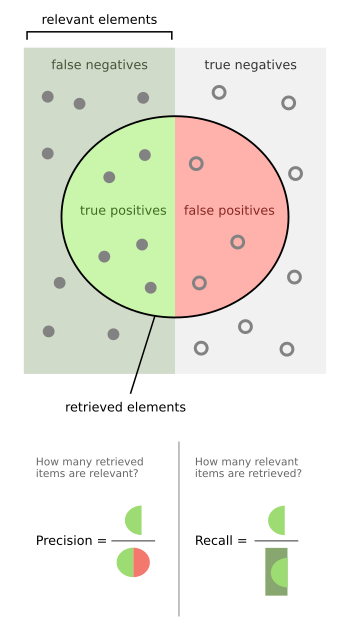

---

### **F1 Score**

Precision and Recall often conflict with each other:

- Increasing recall may decrease precision.
- Increasing precision may decrease recall.

The **F1 score** combines these two metrics into a single value.

Conceptually:

- It is high only when **both precision and recall are high**.
- If either one is low, the F1 score also decreases.

This makes F1 a strong general-purpose metric for **imbalanced classification problems**.

---

### **Balanced Error Metric**

The `"balanced"` option focuses on the **types of mistakes** the classifier makes.

To analyze this, we use the **confusion matrix**, which contains four values:

- **TP (True Positives)** — correctly predicted positives  
- **TN (True Negatives)** — correctly predicted negatives  
- **FP (False Positives)** — negatives incorrectly predicted as positive  
- **FN (False Negatives)** — positives incorrectly predicted as negative  

From these values, we compute two important error rates:

**False Positive Rate (FPR)**  
The proportion of negative samples that were incorrectly predicted as positive:

$$
FPR = \frac{FP}{FP + TN}
$$

**False Negative Rate (FNR)**  
The proportion of positive samples that were incorrectly predicted as negative:

$$
FNR = \frac{FN}{FN + TP}
$$

The goal of the balanced metric is to **reduce the difference between these two error rates**.  
A well-balanced classifier should not heavily favor one type of error over the other.

To convert this idea into a score where **higher = better balance**, one possible formulation is:

$$
Score = 1 - |FPR - FNR|
$$

With this definition:

- When $FPR$ and $FNR$ are equal, the score is maximized (approaching $1.0$).
- When one error rate dominates the other, the score decreases.

---

### **Step 5 — Track the Best Threshold**

As each threshold is evaluated, its score is compared with the best score found so far.

If the current threshold achieves a higher score:

- The best threshold should be updated.
- The best score should also be updated.

---

### **Step 6 — Store the Optimal Threshold**

After evaluating all candidate thresholds, the best threshold is stored inside the model.

This value will be used later during prediction when converting probabilities into class labels.

Finally, the function reports:

- the **optimal threshold**
- the **score achieved by that threshold**

This ensures that future predictions align with the selected evaluation objective.


In [15]:
dt_tune = DecisionTree()

# Mocking predict_proba for the validation set
dt_tune.predict_proba = lambda X: np.array([
    [0.9, 0.1],
    [0.6, 0.4],
    [0.4, 0.6],
    [0.2, 0.8]
])
dt_tune.classes_ = np.array([0, 1])

# Validation labels
X_val_dummy = np.zeros((4, 2))
y_val = np.array([0, 0, 1, 1])

# Tune threshold - Unpack the tuple here!
best_thresh, best_score = dt_tune.tune_threshold(X_val_dummy, y_val, metric='f1', target_class=1)

assert isinstance(best_thresh, float) or isinstance(best_thresh, np.floating), "tune_threshold must return a float."
assert 0.0 <= best_thresh <= 1.0, "Best threshold must be between 0.0 and 1.0."

# For this mock setup, threshold > 0.4 and <= 0.6 perfectly separates the classes 
# (giving F1=1.0). The tuned threshold should reflect this range.
assert 0.4 <= best_thresh <= 0.6, f"tune_threshold found suboptimal threshold: {best_thresh}"

print(f"Test for tune_threshold passed! Best Threshold: {best_thresh:.3f}, Score: {best_score:.4f}")


Test for tune_threshold passed! Best Threshold: 0.410, Score: 1.0000


# complete analysis with hotel_booking.csv

## 1. Data Preparation & Exploration

### 1.1 Data Loading and Basic Preprocessing
Real-world data is rarely ready to be fed directly into a Machine Learning model. Before training our Decision Tree, we need to load the dataset and prepare it. Decision Trees require numerical inputs and cannot handle missing values natively, so cleaning is our first priority.

**Key Preprocessing Steps to Perform:**
* **Handling Missing Values:** Inspect the dataset for `NaN` (null) values. Decide how to handle them (e.g., filling them with default values like 0, or dropping rows/columns if too much data is missing).
* **Categorical Encoding:** Algorithms do math, so they need numbers. Convert text-based categorical columns (like categories, countries, or types) into numerical codes.
* **Preventing Data Leakage:** This is a crucial step! Remove any columns that "look into the future." If a feature contains information that you wouldn't actually know at the time you need to make a prediction (e.g., the final recorded status of a booking), it will allow the model to "cheat" during training but fail completely in real life.

📦Import ها و تنظیمات اولیه

In [16]:
# ================================================================
#  📦 وارد کردن کتابخانه‌ها
# ================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# فونت فارسی (اختیاری)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 12

# وارد کردن کتابخانه درخت تصمیم خودمان
from DT_Library import DecisionTree

print("✅ کتابخانه‌ها با موفقیت بارگذاری شدند.")


✅ کتابخانه‌ها با موفقیت بارگذاری شدند.


📦 بارگذاری داده

In [17]:
# ================================================================
#  📂 بارگذاری داده‌ها
# ================================================================
df = pd.read_csv('hotel_bookings.csv')

print(f"📊 ابعاد داده: {df.shape}")
print(f"📋 ستون‌ها: {list(df.columns)}")
print(f"\n🔍 ۵ سطر اول:")
df.head()

📊 ابعاد داده: (119390, 32)
📋 ستون‌ها: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

🔍 ۵ سطر اول:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


📦 بررسی اولیه داده

In [18]:
# ================================================================
#  🔍 بررسی اولیه
# ================================================================
print("=" * 60)
print("📊 اطلاعات کلی داده:")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("📉 مقادیر گمشده:")
print("=" * 60)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

print("\n" + "=" * 60)
print("🎯 توزیع متغیر هدف (is_canceled):")
print("=" * 60)
print(df['is_canceled'].value_counts())
print(f"\nنرخ لغو: {df['is_canceled'].mean():.2%}")

# نمایش آمار توصیفی
df.describe(include='all').T.head(15)

📊 اطلاعات کلی داده:
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal   

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


📦 پاک‌سازی داده — مدیریت مقادیر گمشده

In [19]:
# ================================================================
#  🧹 پاک‌سازی داده — مدیریت Null ها
# ================================================================

# --- ستون‌های عددی: پر کردن با میانه ---
numeric_cols_with_null = ['children', 'agent', 'company']

for col in numeric_cols_with_null:
    if col in df.columns and df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"✅ {col}: {df[col].isnull().sum()} مقدار گمشده → پر شده با میانه = {median_val}")

# --- ستون‌های متنی: پر کردن با مد (پرتکرارترین) ---
categorical_cols_with_null = ['country', 'market_segment', 'distribution_channel']

for col in categorical_cols_with_null:
    if col in df.columns and df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"✅ {col}: {df[col].isnull().sum()} مقدار گمشده → پر شده با مد = '{mode_val}'")

# --- meal: مقادیر Undefined را به 'Undefined' تبدیل کن ---
if 'meal' in df.columns:
    df['meal'] = df['meal'].fillna('Undefined')

print("\n🎉 پاک‌سازی مقادیر گمشده کامل شد!")
print(f"تعداد مقادیر گمشده باقی‌مانده: {df.isnull().sum().sum()}")


✅ children: 0 مقدار گمشده → پر شده با میانه = 0.0
✅ agent: 0 مقدار گمشده → پر شده با میانه = 14.0
✅ company: 0 مقدار گمشده → پر شده با میانه = 179.0
✅ country: 0 مقدار گمشده → پر شده با مد = 'PRT'

🎉 پاک‌سازی مقادیر گمشده کامل شد!
تعداد مقادیر گمشده باقی‌مانده: 0


### 1.2 Feature Engineering
Sometimes the raw data isn't enough for a model to capture the underlying patterns effectively. By transforming or combining existing columns, we can create **new features** that make it easier for our Decision Tree to find good splitting criteria.

**Types of Features to Create:**
* **Composite Features:** Combine multiple related columns into a single total (e.g., adding up different types of people to get a total count, or adding weekend and weekday metrics together).
* **Binary Flags:** Create simple 1/0 (True/False) columns to capture specific conditions (e.g., "Is this a large group?" or "Does this involve an extended duration?").
* **Ratios and Averages:** Raw numbers can be misleading. Calculating per-person or per-day ratios often provides a much better representation of value or behavior.
* **Binning Continuous Variables:** Sometimes, grouping a continuous number (like days in advance) into categorical buckets (e.g., "Last Minute", "Normal", "Early Bird") helps the tree generalize better.
* **Historical Behavior:** If available, combine past behaviors to create a single "score" (e.g., a reliability or loyalty score).


📦 مهندسی ویژگی

In [20]:
# ================================================================
#  🛠️ مهندسی ویژگی
# ================================================================

# ۱. تعداد کل مهمانان
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# ۲. آیا رزرو شامل کودک است؟
df['has_children'] = ((df['children'] + df['babies']) > 0).astype(int)

# ۳. طول اقامت (تعداد شب)
df['stay_length'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# ۴. آیا رزرو قبلاً لغو شده؟
df['previous_cancellations_binary'] = (df['previous_cancellations'] > 0).astype(int)

# ۵. آیا درخواست خاص داشته؟
df['has_special_requests'] = (df['total_of_special_requests'] > 0).astype(int)

# ۶. تعداد شب‌های آخر هفته نسبت به کل اقامت
df['weekend_ratio'] = np.where(
    df['stay_length'] > 0,
    df['stays_in_weekend_nights'] / df['stay_length'],
    0
)

print("✅ ویژگی‌های جدید ساخته شدند:")
new_features = ['total_guests', 'has_children', 'stay_length',
                'previous_cancellations_binary', 'has_special_requests', 'weekend_ratio']
print(df[new_features].describe().T)

✅ ویژگی‌های جدید ساخته شدند:
                                  count      mean       std  min  25%   50%  \
total_guests                   119390.0  1.968239  0.722394  0.0  2.0  2.00   
has_children                   119390.0  0.078164  0.268431  0.0  0.0  0.00   
stay_length                    119390.0  3.427900  2.557439  0.0  2.0  3.00   
previous_cancellations_binary  119390.0  0.054309  0.226628  0.0  0.0  0.00   
has_special_requests           119390.0  0.411023  0.492021  0.0  0.0  0.00   
weekend_ratio                  119390.0  0.253179  0.280536  0.0  0.0  0.25   

                               75%   max  
total_guests                   2.0  55.0  
has_children                   0.0   1.0  
stay_length                    4.0  69.0  
previous_cancellations_binary  0.0   1.0  
has_special_requests           1.0   1.0  
weekend_ratio                  0.4   1.0  


📦 تبدیل متغیرهای کیفی به عددی

In [21]:
# ================================================================
#  🔄 تبدیل متغیرهای کیفی (Encoding)
# ================================================================

# --- ۱. hotel: Resort → 0, City → 1 ---
df['hotel'] = df['hotel'].map({'Resort Hotel': 0, 'City Hotel': 1})

# --- ۲. ماه ورود: نام ماه → عدد ---
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['arrival_date_month'] = df['arrival_date_month'].map(month_map)

# --- ۳. meal: کدگذاری دستی ---
meal_map = {'SC': 0, 'BB': 1, 'HB': 2, 'FB': 3, 'Undefined': 4}
df['meal'] = df['meal'].map(meal_map).fillna(4)

# --- ۴. market_segment: کدگذاری ---
segment_map = {
    'Direct': 0, 'Corporate': 1, 'Online TA': 2,
    'Offline TA/TO': 3, 'Complementary': 4, 'Groups': 5,
    'Undefined': 6, 'Aviation': 7
}
df['market_segment'] = df['market_segment'].map(segment_map).fillna(6)

# --- ۵. distribution_channel: کدگذاری ---
channel_map = {
    'Direct': 0, 'Corporate': 1, 'TA/TO': 2,
    'Undefined': 3, 'GDS': 4
}
df['distribution_channel'] = df['distribution_channel'].map(channel_map).fillna(3)

# --- ۶. deposit_type: کدگذاری ---
deposit_map = {'No Deposit': 0, 'Refundable': 1, 'Non Refund': 2}
df['deposit_type'] = df['deposit_type'].map(deposit_map).fillna(0)

# --- ۷. customer_type: کدگذاری ---
cust_map = {'Transient': 0, 'Contract': 1, 'Transient-Party': 2, 'Group': 3}
df['customer_type'] = df['customer_type'].map(cust_map).fillna(0)

# --- ۸. reserved_room_type و assigned_room_type: کدگذاری حروف ---
for col in ['reserved_room_type', 'assigned_room_type']:
    if col in df.columns:
        df[col] = df[col].astype('category').cat.codes

# --- ۹. country: گروه‌بندی کشورهای کم‌تکرار + One-Hot Encoding ---
top_countries = df['country'].value_counts().head(10).index.tolist()
df['country'] = df['country'].apply(lambda x: x if x in top_countries else 'Other')
df = pd.get_dummies(df, columns=['country'], prefix='country', drop_first=True)

print(f"✅ تبدیل متغیرهای کیفی کامل شد. ابعاد جدید: {df.shape}")
print(f"ستون‌های جدید country: {[c for c in df.columns if c.startswith('country_')]}")


✅ تبدیل متغیرهای کیفی کامل شد. ابعاد جدید: (119390, 47)
ستون‌های جدید country: ['country_BRA', 'country_DEU', 'country_ESP', 'country_FRA', 'country_GBR', 'country_IRL', 'country_ITA', 'country_NLD', 'country_Other', 'country_PRT']


## **Part 1 — Node Class**

### **What is a Node?**

What is a Node?
A Node is the basic building block of the Decision Tree.

Each Node can be:

an internal node (splits data based on a feature and threshold), or
a leaf node (stores the final predicted class)

Follow the TODOs carefully—later parts of the notebook and all tree operations depend on this class working correctly.

### 1.3 Feature Selection
Not all features are useful. Having too many irrelevant features can slow down the training process of a Decision Tree and lead to overfitting. 

**What we are doing here:**
We apply a custom feature selection function (`heatmap_gini_filter_clean`) to filter out features that have very little relationship with our target variable (`is_canceled`). We use a specific threshold to ensure we only keep the most informative features, and then display the top 10 most important ones.


📦 حذف ستون‌های غیرضروری

In [22]:
# ================================================================
#  🗑️ حذف ستون‌های غیرضروری
# ================================================================

# ستون‌هایی که نباید در مدل استفاده شوند
cols_to_drop = [
    'reservation_status',          # اطلاعات آینده (نشت داده)
    'reservation_status_date',     # تاریخ وضعیت رزرو
    'arrival_date_year',           # سال ثابت است یا نشت داده
    'arrival_date_week_number',    # همبستگی بالا با ماه
    'arrival_date_day_of_month',   # جزئیات زیاد
    'days_in_waiting_list',        # ممکن است نشت داده باشد (اختیاری)
]

# فقط ستون‌هایی که واقعاً وجود دارند حذف کن
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)

print(f"✅ ستون‌های حذف شده: {cols_to_drop}")
print(f"📊 ابعاد نهایی داده: {df.shape}")
print(f"📋 ستون‌های باقی‌مانده: {list(df.columns)}")

✅ ستون‌های حذف شده: ['reservation_status', 'reservation_status_date', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'days_in_waiting_list']
📊 ابعاد نهایی داده: (119390, 41)
📋 ستون‌های باقی‌مانده: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_guests', 'has_children', 'stay_length', 'previous_cancellations_binary', 'has_special_requests', 'weekend_ratio', 'country_BRA', 'country_DEU', 'country_ESP', 'country_FRA', 'country_GBR', 'country_IRL', 'country_ITA', 'country_NLD', 'country_Other', 'country_PRT']


### 1.4 Stratified Data Splitting
Before training the model, we must split our data into three distinct sets: **Training**, **Validation**, and **Testing**.

**What we are doing here:**
* We use a $60\%$ (Train) / $20\%$ (Validation) / $20\%$ (Test) split.
* Notice the `stratify=y` argument. This is crucial for imbalanced datasets. It ensures that the ratio of "Canceled" to "Not Canceled" bookings remains exactly the same across all three sets, preventing our model from being trained or evaluated on a skewed sample.


📦 تقسیم داده به train / val / test

In [23]:
# ================================================================
#  ✂️ تقسیم داده (۶۰٪ آموزش، ۲۰٪ اعتبارسنجی، ۲۰٪ تست)
# ================================================================

# جدا کردن X و y
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

print(f"🎯 توزیع هدف: \n{y.value_counts()}")
print(f"📊 نرخ لغو کلی: {y.mean():.2%}")

# مرحله ۱: جدا کردن ۴۰٪ برای تست + اعتبارسنجی
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

# مرحله ۲: تقسیم ۴۰٪ به دو بخش مساوی (۲۰٪ اعتبارسنجی + ۲۰٪ تست)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"\n📊 ابعاد مجموعه‌ها:")
print(f"  🟦 آموزش (Train) : {X_train.shape} | نرخ لغو: {y_train.mean():.2%}")
print(f"  🟨 اعتبارسنجی (Val): {X_val.shape} | نرخ لغو: {y_val.mean():.2%}")
print(f"  🟥 تست (Test)    : {X_test.shape} | نرخ لغو: {y_test.mean():.2%}")

# تبدیل به numpy array برای سرعت
y_train = y_train.values
y_val = y_val.values
y_test = y_test.values

print("\n✅ تقسیم داده کامل شد!")


🎯 توزیع هدف: 
is_canceled
0    75166
1    44224
Name: count, dtype: int64
📊 نرخ لغو کلی: 37.04%

📊 ابعاد مجموعه‌ها:
  🟦 آموزش (Train) : (71634, 40) | نرخ لغو: 37.04%
  🟨 اعتبارسنجی (Val): (23878, 40) | نرخ لغو: 37.04%
  🟥 تست (Test)    : (23878, 40) | نرخ لغو: 37.04%

✅ تقسیم داده کامل شد!


### 2.1 Strategy 1: Baseline Model (No Class Weights)
Before trying advanced techniques, we must establish a baseline. This tells us how a standard Decision Tree performs out-of-the-box. 

**What we are doing here:**
We train a standard model with `class_weight=None`. We will evaluate its Accuracy, Recall, and F1-score. Because our dataset has a class imbalance (more non-canceled than canceled bookings), we expect the model to favor the majority class, potentially resulting in poor Recall for the "Canceled" (Class 1) category.


### 2.2 Strategy 2: Balanced Class Weights
To combat the bias towards the majority class, we can use our implemented `class_weight="balanced"` feature.

**What we are doing here:**
The model will automatically calculate weights inversely proportional to class frequencies. The minority class (Cancellations) will be given a higher weight, meaning the model will be penalized more heavily for misclassifying a cancellation during training. We expect to see an improvement in Recall for Class 1.


### 2.3 Strategy 3: Custom Class Weights (More Aggressive)
Sometimes auto-balancing isn't enough, or the business requires a specific tradeoff. We can explicitly define how much more important one class is over the other.

**What we are doing here:**
We pass a dictionary `class_weight={...}`. This explicitly tells the Decision Tree that correctly identifying a cancellation (Class 1) is **twice as important** as correctly identifying a standard booking.


### 2.4 Strategy 4: Balanced Weights + Threshold Tuning (F1 Optimization)
During prediction, the tree normally uses a 50% probability threshold to decide between Class 0 and Class 1. We can shift this threshold to optimize for a specific metric.

**What we are doing here:**
We use the `tune_threshold` method we wrote earlier to find the exact probability cutoff that maximizes the **F1-score** (the harmonic mean of Precision and Recall) on the validation set, rather than just using the default 0.5.


### 2.5 Strategy 5: Balanced Weights + Threshold Tuning (Recall Optimization)
What if the hotel management says: *"We want to catch as many potential cancellations as possible, even if it means a few false alarms!"*

**What we are doing here:**
We tune the threshold again, but this time we explicitly optimize for **Recall**. We expect the threshold to drop significantly lower than 0.5, catching more true cancellations but likely sacrificing some Precision (increasing false positives).


### 2.6 Strategy 6: Deeper Tree + Balanced Weights
Up to this point, we restricted our tree to `max_depth=15`. Let's see if allowing the tree to learn more complex rules improves performance or if it just leads to overfitting.

**What we are doing here:**
We increase `max_depth` to 20 while keeping the balanced class weights. We will check if the validation metrics improve compared to Strategy 2.


### 2.7 Strategy 7: Grid Search for Hyperparameter Tuning
While we manually tested different combinations of tree depth and class weights in the previous strategies, a more systematic and automated approach is to use **Grid Search**.

**What we are doing here:**
Instead of guessing, we define a grid of hyperparameters (such as various values for `max_depth`, `min_samples_split`, `min_samples_leaf`, and `class_weight`). We will iterate through all possible combinations, evaluate their performance on our Validation set, and automatically extract the exact model configuration that yields the highest target metric (like F1-score or Recall).

📦  تعریف ۷ استراتژی

In [24]:
# ================================================================
#  🎯 تعریف ۷ استراتژی مختلف
# ================================================================

strategies = {
    "1. Baseline (Gini, بدون وزن)": DecisionTree(
        mode="gini", max_depth=None, min_samples_split=2,
        class_weight=None
    ),
    "2. Entropy (بدون وزن)": DecisionTree(
        mode="entropy", max_depth=None, min_samples_split=2,
        class_weight=None
    ),
    "3. Balanced (Gini + وزن‌دهی متوازن)": DecisionTree(
        mode="gini", max_depth=None, min_samples_split=2,
        class_weight="balanced"
    ),
    "4. Balanced + Entropy": DecisionTree(
        mode="entropy", max_depth=None, min_samples_split=2,
        class_weight="balanced"
    ),
    "5. عمق محدود (max_depth=5)": DecisionTree(
        mode="gini", max_depth=5, min_samples_split=2,
        class_weight="balanced"
    ),
    "6. عمق محدود (max_depth=10)": DecisionTree(
        mode="gini", max_depth=10, min_samples_split=2,
        class_weight="balanced"
    ),
    "7. تنظیم آستانه (Tuned Threshold)": DecisionTree(
        mode="gini", max_depth=8, min_samples_split=5,
        class_weight="balanced"
    ),
}

print("✅ ۷ استراتژی تعریف شدند:")
for name, model in strategies.items():
    print(f"  • {name}")


✅ ۷ استراتژی تعریف شدند:
  • 1. Baseline (Gini, بدون وزن)
  • 2. Entropy (بدون وزن)
  • 3. Balanced (Gini + وزن‌دهی متوازن)
  • 4. Balanced + Entropy
  • 5. عمق محدود (max_depth=5)
  • 6. عمق محدود (max_depth=10)
  • 7. تنظیم آستانه (Tuned Threshold)


📦 آموزش و ارزیابی همه استراتژی‌ها

In [25]:
# ================================================================
#  🚀 آموزش و ارزیابی همه استراتژی‌ها
# ================================================================

from IPython.display import display, Markdown

results = {}

for name, model in strategies.items():
    
    # بلوک عنوان مدل
    display(Markdown(f"## 🔧 آموزش مدل: `{name}`"))
    
    # ---- آموزش ----
    model.fit(X_train, y_train)

    # ---- ارزیابی اولیه Validation ----
    val_results = model.evaluate(X_val, y_val, dataset_name=f"{name} — Validation")

    # ---- تنظیم آستانه (برای مدل‌های Tuned) ----
    if "Tuned" in name:
        best_thr, best_score = model.tune_threshold(X_val, y_val, metric='f1')
        display(Markdown(f"**🎯 آستانه بهینه:** `{best_thr:.3f}` — F1=`{best_score:.4f}`"))
        
        # ارزیابی مجدد با آستانه جدید
        val_results = model.evaluate(X_val, y_val, dataset_name=f"{name} — Validation (Tuned)")

    # ذخیره نتایج
    results[name] = {
        "model": model,
        "val_results": val_results
    }

    # جداکننده بین مدل‌ها
    display(Markdown("---"))


## 🔧 آموزش مدل: `1. Baseline (Gini, بدون وزن)`

Class distribution: {np.int64(0): np.int64(45100), np.int64(1): np.int64(26534)}

📊 نتایج 1. Baseline (Gini, بدون وزن) — Validation:
   dataset: 1. Baseline (Gini, بدون وزن) — Validation
   accuracy: 0.8405
   precision: 0.7815
   recall: 0.7905
   f1: 0.7860
   confusion_matrix:
[[13078  1955]
 [ 1853  6992]]


---

## 🔧 آموزش مدل: `2. Entropy (بدون وزن)`

Class distribution: {np.int64(0): np.int64(45100), np.int64(1): np.int64(26534)}

📊 نتایج 2. Entropy (بدون وزن) — Validation:
   dataset: 2. Entropy (بدون وزن) — Validation
   accuracy: 0.8441
   precision: 0.7839
   recall: 0.7995
   f1: 0.7916
   confusion_matrix:
[[13083  1950]
 [ 1773  7072]]


...

## 🔧 آموزش مدل: `7. تنظیم آستانه (Tuned Threshold)`

Class distribution: {np.int64(0): np.int64(45100), np.int64(1): np.int64(26534)}
Class weights: {np.int64(0): np.float64(0.7941685144124169), np.int64(1): np.float64(1.3498530187683726)}

📊 نتایج 7. تنظیم آستانه (Tuned Threshold) — Validation:
   dataset: 7. تنظیم آستانه (Tuned Threshold) — Validation
   accuracy: 0.8226
   precision: 0.8071
   recall: 0.6849
   f1: 0.7410
   confusion_matrix:
[[13585  1448]
 [ 2787  6058]]


**🎯 آستانه بهینه:** `0.390` — F1=`0.7599`


📊 نتایج 7. تنظیم آستانه (Tuned Threshold) — Validation (Tuned):
   dataset: 7. تنظیم آستانه (Tuned Threshold) — Validation (Tuned)
   accuracy: 0.8224
   precision: 0.7613
   recall: 0.7585
   f1: 0.7599
   confusion_matrix:
[[12929  2104]
 [ 2136  6709]]


---

## 3. Final Test Set Evaluation
After comparing all strategies on the **Validation Set**, we select the best performing model. Now, we must evaluate it one final time on the unseen **Test Set**.

**What we are doing here:**
1. We run `.predict()` using our best overall strategy on `X_test`.
2. We print a full classification report to see precision, recall, and f1-scores for both classes.
3. We compare the final True Positives and False Negatives against our initial Baseline Model to quantify exactly how much our enhancements (class weights and threshold tuning) improved the business outcome.


In [26]:
# ================================================================
#  📊 ارزیابی نهایی روی داده تست
# ================================================================

print("\n" + "="*70)
print("🏁 ارزیابی نهایی روی داده TEST")
print("="*70)

final_results = []

for name, res in results.items():
    model = res["model"]
    thr   = res.get("threshold", None)   # Use tuned threshold if available
    
    test_res = model.evaluate(X_test, y_test, dataset_name=f"{name} — Test")
    
    final_results.append({
        "استراتژی"   : name,
        "Accuracy"   : test_res["accuracy"],
        "Precision"  : test_res["precision"],
        "Recall"     : test_res["recall"],
        "F1-Score"   : test_res["f1"],
    })

# ── Convert to DataFrame for clean comparison ──
df_final = pd.DataFrame(final_results)
df_final.set_index("استراتژی", inplace=True)

print("\n" + "="*70)
print("📋 جدول مقایسه‌ای — نتایج نهایی روی Test Set")
print("="*70)
print(df_final.to_string(float_format="%.4f"))

# ── Highlight the best model ──
best_idx = df_final["F1-Score"].idxmax()
print("\n" + "="*70)
print(f"🏆 بهترین مدل بر اساس F1-Score: **{best_idx}**")
print(f"   F1={df_final.loc[best_idx, 'F1-Score']:.4f}  |  "
      f"Recall={df_final.loc[best_idx, 'Recall']:.4f}  |  "
      f"Precision={df_final.loc[best_idx, 'Precision']:.4f}")
print("="*70)



🏁 ارزیابی نهایی روی داده TEST

📊 نتایج 1. Baseline (Gini, بدون وزن) — Test:
   dataset: 1. Baseline (Gini, بدون وزن) — Test
   accuracy: 0.8476
   precision: 0.7931
   recall: 0.7963
   f1: 0.7947
   confusion_matrix:
[[13196  1837]
 [ 1802  7043]]

📊 نتایج 2. Entropy (بدون وزن) — Test:
   dataset: 2. Entropy (بدون وزن) — Test
   accuracy: 0.8508
   precision: 0.7978
   recall: 0.8001
   f1: 0.7989
   confusion_matrix:
[[13239  1794]
 [ 1768  7077]]

📊 نتایج 3. Balanced (Gini + وزن‌دهی متوازن) — Test:
   dataset: 3. Balanced (Gini + وزن‌دهی متوازن) — Test
   accuracy: 0.8488
   precision: 0.7993
   recall: 0.7902
   f1: 0.7947
   confusion_matrix:
[[13278  1755]
 [ 1856  6989]]

📊 نتایج 4. Balanced + Entropy — Test:
   dataset: 4. Balanced + Entropy — Test
   accuracy: 0.8486
   precision: 0.7990
   recall: 0.7899
   f1: 0.7944
   confusion_matrix:
[[13275  1758]
 [ 1858  6987]]

📊 نتایج 5. عمق محدود (max_depth=5) — Test:
   dataset: 5. عمق محدود (max_depth=5) — Test
   accuracy: 0.78

## 4. Visualizing the Final Decision Tree
One of the greatest advantages of Decision Trees over "black-box" models (like Neural Networks) is their **interpretability**. We can visually inspect the exact logical rules and thresholds the model learned from the data.

**What we are doing here:**
We will generate a graphical representation of our best-performing tree. Because real-world trees can get massive (e.g., depths of 15 or 20), we will restrict the visualization to just the top few levels. This allows us to easily see the most dominant features (the root node and its immediate children) that drive hotel cancellations.

In [28]:
# ================================================================
# ۴. Visualizing the Final Decision Tree
# ================================================================

# پیدا کردن بهترین مدل بر اساس ارزیابی روی تست
best_name = df_final["F1-Score"].idxmax()
best_model_info = results[best_name]
best_model = best_model_info["model"]

print(f"🌳 بهترین مدل: **{best_name}**")
print(f"   F1 = {df_final.loc[best_name, 'F1-Score']:.4f}")
print(f"   تعداد کل نودهای درخت: {best_model._count_nodes() if hasattr(best_model, '_count_nodes') else 'نامشخص'}")

# ── تصویر ۳ سطح اول درخت ──
print("\n📸 تصویر ۳ سطح اول درخت تصمیم (مهم‌ترین ویژگی‌ها):")
best_model.visualize_tree(filename="best_decision_tree", format="png")

# ── (اختیاری) تصویر ۲ سطح اول با سایز کوچک‌تر برای گزارش ──
# best_model.visualize_tree(max_depth=2, figsize=(12, 6))


🌳 بهترین مدل: **2. Entropy (بدون وزن)**
   F1 = 0.7989
   تعداد کل نودهای درخت: نامشخص

📸 تصویر ۳ سطح اول درخت تصمیم (مهم‌ترین ویژگی‌ها):


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH